## Question 3: KDE and ECDF for Annotation 208 Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.neighbors import KernelDensity

df_annotation_208 = pd.read_csv("/home/tiyeh21/ds5030-project1/mit-bih-arrhythmia-database-1.0.0/extracted_records/208_annotations.csv")
df_annotation_208.head()
df_annotation_208.columns

Index(['Sample', 'Symbol', 'Subtype', 'Chan', 'Num'], dtype='object')

In [2]:
df_annotation_208.isnull().sum()

Sample     0
Symbol     0
Subtype    0
Chan       0
Num        0
dtype: int64

First 15 RR Intervals: [0.10277778 0.45277778 0.76111111 0.59444444 0.43333333 0.91111111
 0.54722222 0.55833333 0.78055556 0.55       0.51111111 0.87777778
 0.525      0.50833333 0.75277778]
Number of beats: 3039


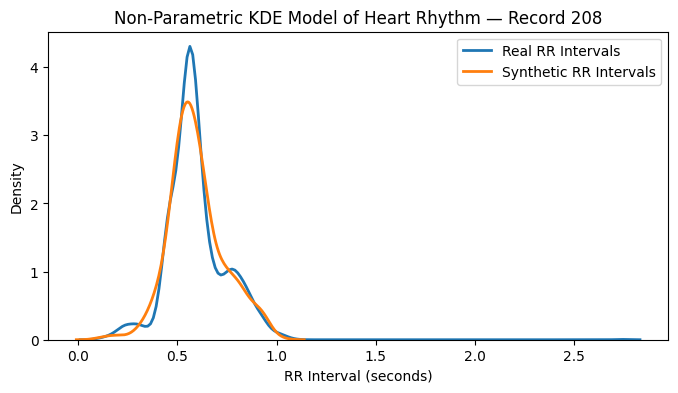

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_annotation_208 = df_annotation_208.sort_values(by="Sample").reset_index(drop=True)


fs = 360  #  this represents the sampling rate in Hz
R_peaks = df_annotation_208["Sample"].values
RR_intervals = np.diff(R_peaks) / fs  # Here, we convert seconds 

print("First 15 RR Intervals:", RR_intervals[:15])
print("Number of beats:", len(RR_intervals))


RR = RR_intervals.reshape(-1, 1)
kde = KernelDensity(kernel="gaussian", bandwidth=0.05).fit(RR)


synthetic_RR = kde.sample(500).flatten() # Chose a 500 sample size


plt.figure(figsize=(8, 4))
sns.kdeplot(RR_intervals, label="Real RR Intervals", linewidth=2)
sns.kdeplot(synthetic_RR, label="Synthetic RR Intervals", linewidth=2)
plt.xlabel("RR Interval (seconds)")
plt.ylabel("Density")
plt.title("Non-Parametric KDE Model of Heart Rhythm — Record 208")
plt.legend()
plt.show()


RR interval is the time between two consecutive beats (two R-Peaks on the ECG). The sampling rate frequency is 360, which means that 360 data points per a second are recorded by the ECG signal. This means that dividing the difference in sample indices by 360 gives the RR interval in seconds. Without this conversion, the sample indicies in the "Sample" column would only represent the positions of the R peaks. The first few interval is between 0.45 - 0.75 which correspond to heart rate of around 80-130 bpm. 

Both the actual distribution of the RR and the artifical RR interval sampled from the KDE model have strong peaks at around 0.5 -0.6. This indicates a heart beat of around 100-120 bpm which is fairly normal. 

Because both curves correspond with each other, the KDE capture the statistical shape of the actual RR interval distribution - meaning the model accurately captures the heart rate characterstic for ECG records. 

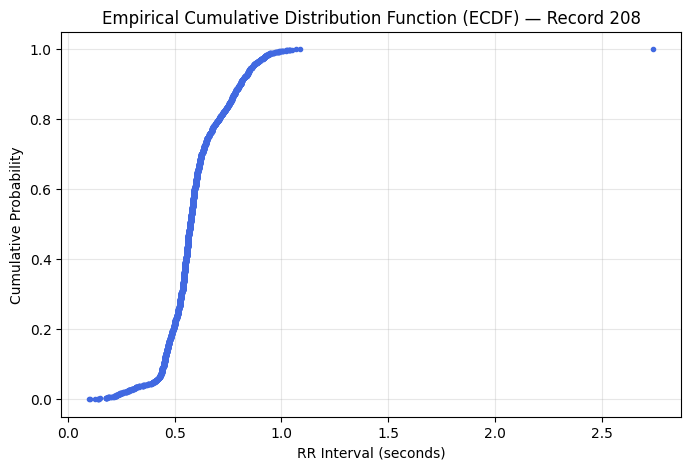

Mean RR interval: 0.594 sec
Median RR interval: 0.572 sec
Number of intervals: 3039


In [4]:
fs = 360  # this represents the sampling frequency in Hz   
RR_intervals = np.diff(df_annotation_208["Sample"]) / fs


def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(data) + 1) / len(data)
    return x, y


x_ecdf, y_ecdf = ecdf(RR_intervals)


plt.figure(figsize=(8, 5))
plt.plot(x_ecdf, y_ecdf, marker='.', linestyle='none', color='royalblue')
plt.xlabel("RR Interval (seconds)")
plt.ylabel("Cumulative Probability")
plt.title("Empirical Cumulative Distribution Function (ECDF) — Record 208")
plt.grid(True, alpha=0.3)
plt.show()


print(f"Mean RR interval: {np.mean(RR_intervals):.3f} sec")
print(f"Median RR interval: {np.median(RR_intervals):.3f} sec")
print(f"Number of intervals: {len(RR_intervals)}")


The ECDF has a smooth step S shape between 04.5 - 0.7 seconds, showing that most RR intervals fall within this range. The mean RR interval is 0.594 sec which convert to around 101 bpm (60/0.594). The median is slightly lower than the mean, which shows a right skew. This means that most beats are a little faster, but the few slower ones (longer intervals) pull up the average. With such a large sample size, 3039 RR intervals is enough to provide statistically solid estimate. 

## Question 3: KDE and ECDF for Annotation 100 Dataset

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.neighbors import KernelDensity

df_annotation_100 = pd.read_csv("/home/tiyeh21/ds5030-project1/mit-bih-arrhythmia-database-1.0.0/extracted_records/100_annotations.csv")
df_annotation_100.head()
df_annotation_100.columns

Index(['Sample', 'Symbol', 'Subtype', 'Chan', 'Num'], dtype='object')

In [6]:
df_annotation_100.isnull().sum()

Sample     0
Symbol     0
Subtype    0
Chan       0
Num        0
dtype: int64

First 15 RR Intervals: [0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444 0.81111111 0.78888889
 0.77222222 0.83888889 0.85555556]
Number of beats: 2273


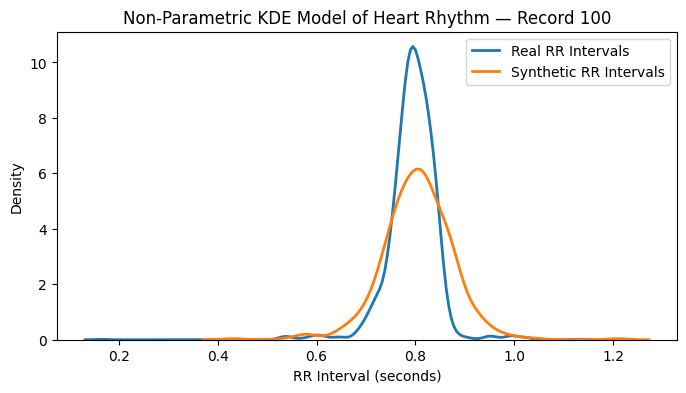

In [7]:

df_annotation_100 = df_annotation_100.sort_values(by="Sample").reset_index(drop=True)


fs = 360  # sampling rate
R_peaks = df_annotation_100["Sample"].values
RR_intervals = np.diff(R_peaks) / fs  # convert to seconds

print("First 15 RR Intervals:", RR_intervals[:15])
print("Number of beats:", len(RR_intervals))


RR = RR_intervals.reshape(-1, 1)
kde = KernelDensity(kernel="gaussian", bandwidth=0.05).fit(RR)

synthetic_RR = kde.sample(500).flatten() # 500 sample size 


plt.figure(figsize=(8, 4))
sns.kdeplot(RR_intervals, label="Real RR Intervals", linewidth=2)
sns.kdeplot(synthetic_RR, label="Synthetic RR Intervals", linewidth=2)
plt.xlabel("RR Interval (seconds)")
plt.ylabel("Density")
plt.title("Non-Parametric KDE Model of Heart Rhythm — Record 100")
plt.legend()
plt.show()


The main peak for both the real and synthetic is around 0.8 seconds. This would convert to a heart rate of around 75 beats per minute (60/0.8). This lies within the normal resting range (typically between 60-100 from a search) which is good. the synthetic curve closely matches the real curve, meaning the kde captures the underlying distribution of the actual RR intervals accurately. The plot virtually shows no data below 0.6 seconds, meaning few rapid beats. Becuase the dataset is extremely large and the model capture the underlying distribution, the model captures normal cardiac activity. 

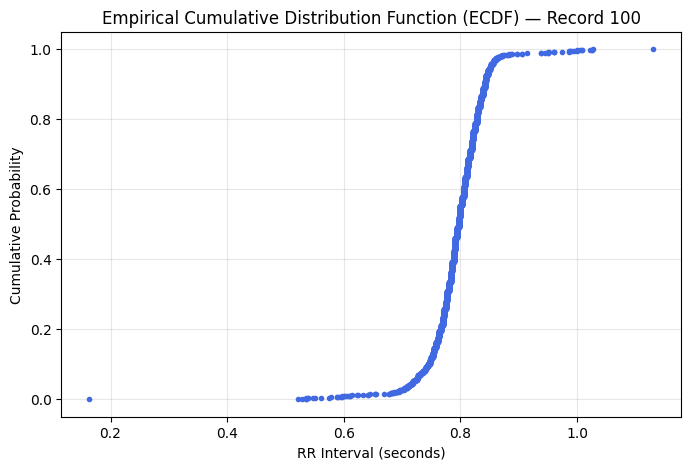

Mean RR interval: 0.794 sec
Median RR interval: 0.797 sec
Number of intervals: 2273


In [8]:
import numpy as np
import matplotlib.pyplot as plt


fs = 360  # sampling frequency in Hz
RR_intervals = np.diff(df_annotation_100["Sample"]) / fs  


def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(data) + 1) / len(data)
    return x, y


x_ecdf, y_ecdf = ecdf(RR_intervals)


plt.figure(figsize=(8, 5))
plt.plot(x_ecdf, y_ecdf, marker='.', linestyle='none', color='royalblue')
plt.xlabel("RR Interval (seconds)")
plt.ylabel("Cumulative Probability")
plt.title("Empirical Cumulative Distribution Function (ECDF) — Record 100")
plt.grid(True, alpha=0.3)
plt.show()


print(f"Mean RR interval: {np.mean(RR_intervals):.3f} sec")
print(f"Median RR interval: {np.median(RR_intervals):.3f} sec")
print(f"Number of intervals: {len(RR_intervals)}")


The mean RR interval of 0.794 seconds converts to around 76 beats per minute (60/0.794), meaning that it rests within a normal heart range. The median and mean are pretty much the same, meaning the RR intervals are evenly distributed around the center. the vertical rise between 0.75 and 0.85 shows that the RR intervals fall within a tight range. There are a few outliers but nothing significant. Compared to 208, the subjects heart beats are more slow and consistent. The large sample size and consistent shape makes this a reliable model. 

# Summary and Challenges Faced During the Analysis

To recap, a kernel Density Estimate plot estimates the probability distribution plot, showing us the distribution of the data and where values are concentrated (density). Because both KDEs have one single sharp peaks, this tells us that the heartbeaks are consistent and steady. ECDF on the other hand tells us the distribution of the data by visualizing the proportion of observations less than or equal to a given  data value. Because both ECDFs have are steep, this tells us that the RR intervals are within a tight range which means the heartbeats are consistent and steady. 

A challenge I faced with making the KDEs was choosing the appropriate sample size for the synthetic data. I knew i didn't want to choose a too small of a sample size (~100) because it would make the data more jagged and not representative of the true shape. I also didn't want to choose a too large of a sample size (~5000) because it would make the data too smooth and hide some of the variation. I ended up with 500 which was a good compromise.